# Sinusoid manifold

Loads the score net from `01_train_score.ipynb`, runs FR-guided sampling via
`driver.guided_reverse_loop`.

Compares:
- **jacobian**: none (ambient R^2) vs. projected onto a rank-1 tangent (`JACOBIAN_TYPE`:
  `"closed-form"` analytic tangent, or `"auto-diff"` jacrev-computed). Energy: k-NN Fisher-Rao
  (`basic_fr.py`), the settled recipe (ambient k-NN FR + relative trust region `eta`).
- **guidance window**: varying the guidance penalty window.
- **eta**: relative trust region, `correction = eta * ||base step|| * grad/||grad||`.
  `eta=1.0` is this manifold's calibrated value, not swept here.

**Metrics**: `mem_ratio` = fraction with `dist_to_nearest/dist_to_2nd_nearest < threshold`;
`fidelity_mse` = mean squared distance to the manifold.

In [ ]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr

REGIME = "normal"   # "normal" or "overtrained" - selects checkpoints/score_{REGIME}_N{N}.pt
N = int(os.environ.get("N_DATA", 20)) # other saved N: 10, 20, 30, 50, 100
JACOBIAN_TYPE = os.environ.get("JACOBIAN_TYPE", "closed-form")   # "closed-form" or "auto-diff"
TAG = f"{REGIME}_N{N}"
ckpt = torch.load(f"checkpoints/score_{TAG}.pt", weights_only=False)
train_config = ckpt["config"]
d, device = train_config["d"], train_config["device"]
X_target = ckpt["X_target"].to(device)
u_target = ckpt["u_target"].to(device)

# this notebook's own outputs, one folder per (N, REGIME) combo
OUT_DIR = f"checkpoints/N{N}-{REGIME}"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"regime={REGIME}  N={N}  d={d}, device={device}, N_data={X_target.shape[0]}, iters={train_config['iters']}")
print(f"outputs -> {OUT_DIR}/")

In [2]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, train_config["hidden"], train_config["depth"]).to(device)
net.load_state_dict(ckpt["net_state"])
net.eval()
print("Loaded score net.")

Loaded score net.


In [ ]:
config = {
    "beta_min": train_config["beta_min"], "beta_max": train_config["beta_max"], "T": train_config["T"],
    "n_steps": 1000,
    "n_samples": 200,
    "seed": 10,
    "k_neighbors": 5,
    "ell": 1,
    "mem_ratio_threshold": 1 / 5,

    # relative trust region; eta=1.0 is this manifold's calibrated value (CIFAR-10 needs 0.1)
    "etas": [0.75],
}


windows = {
    "normal": (0.8, 1)
}

def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1 - alpha_bar(t)).clamp(min=1e-4)

## Wire up the generic interface for sampling and guidance

`base_step_fn(z_t, step_idx) -> z_{t-1}` is the plain reverse SDE step; `y_fn(z_t) -> y` is the denoiser
$D_t(z_t) = (z_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon)/\sqrt{\bar\alpha_t}$.

In [4]:
n_steps = config["n_steps"]
dt = config["T"] / n_steps
t_vec_holder = {"t": None}

def make_base_step_fn():
    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_vec_holder["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5
    return base_step_fn

def y_fn(z_t):
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    a = alpha_bar(t_vec)
    return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()



## Guidance energies

k-NN Fisher-Rao (`basic_fr.fisher_rao_energy`): `beta_t` is pinned to `sigma_t^2`, not a free
hyperparameter to hand-tune.

In [ ]:
index = basic_fr.build_flat_index(X_target)

def make_knn_energy_fn():
    def energy_fn(y):
        with torch.no_grad():
            neighbors, _ = basic_fr.ann_query(index, y, config["k_neighbors"])
        I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2(t_vec_holder["t"]))
        return I
    return energy_fn

ENERGY_FACTORIES = {
    "basic_fr": make_knn_energy_fn,
}

# tangent-projected counterpart: energy_fn(y, P) -> I, restricted to tangent directions by construction
def make_knn_projected_energy_fn():
    return basic_fr.make_knn_projected_energy_fn(index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]))

PROJECTED_ENERGY_FACTORIES = {
    "basic_fr": make_knn_projected_energy_fn,
}

## Tangent Jacobian: closed-form vs. auto-diff (`JACOBIAN_TYPE`)

`JACOBIANS["projected"]` is a rank-1 tangent projector, built from one of two Jacobians:

- **`"closed-form"`** (default): ground-truth tangent of `y = 0.6 sin(2x)`, hand-written.
- **`"auto-diff"`**: real per-sample Jacobian `M = d(score(y,t))/dy` via `jacrev`+`vmap`,
  symmetrized and rescaled by `1/sigma_t^2`, eigendecomposed via `driver.eig_tangent_projector`
  to keep the smallest-`|eigenvalue|` eigenvector. No learned surrogate.

Defined before the diagnostic below so it can plot projected gradient norms too.

In [ ]:
def tangent_vec_from_u(u):
    t = torch.stack([torch.ones_like(u), 1.2 * torch.cos(2 * u)], dim=-1)
    return t / t.norm(dim=-1, keepdim=True)

def analytic_tangent_projector(y):
    u = y[:, 0].clamp(-3.2, 3.2)
    t = tangent_vec_from_u(u)          # [B, 2]
    return torch.einsum("bi,bj->bij", t, t)

# real per-sample d(score(y,t))/dy via jacrev+vmap, symmetrized and rescaled by 1/sigma_t^2
def score_at_single(y_i, t_i):
    eps_hat = net(y_i[None], t_i[None])
    return (-eps_hat / sigma2(t_i[None])[:, None].sqrt())[0]

_score_jacobian_fn = torch.func.vmap(torch.func.jacrev(score_at_single))

def autodiff_jacobian_matrix_fn(y):
    t_vec = t_vec_holder["t"]
    M_raw = _score_jacobian_fn(y, t_vec)
    M_tilde = 0.5 * (M_raw + M_raw.transpose(-1, -2))
    return (M_tilde / sigma2(t_vec)[:, None, None]).detach()

autodiff_tangent_projector = driver.make_projector_fn(autodiff_jacobian_matrix_fn, k=1, largest=False)

_PROJECTED_JACOBIANS = {"closed-form": analytic_tangent_projector, "auto-diff": autodiff_tangent_projector}
assert JACOBIAN_TYPE in _PROJECTED_JACOBIANS, f"JACOBIAN_TYPE must be one of {list(_PROJECTED_JACOBIANS)}"

JACOBIANS = {
    "unprojected": None,
    "projected": _PROJECTED_JACOBIANS[JACOBIAN_TYPE],
}

# denoiser's own Jacobian dy/dz_t (exact, jacrev+vmap): needed to correctly map a y-space
# guidance gradient into z_t-space -- assuming dy/dz_t=identity points the correction in the
# WRONG direction for 50-76% of samples during the noisiest ~20% of the trajectory.
def _y_fn_single(z_i, t_i):
    eps_hat = net(z_i[None], t_i[None])
    a = alpha_bar(t_i[None])
    return ((z_i[None] - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt())[0]

_denoiser_jacobian_fn_raw = torch.func.vmap(torch.func.jacrev(_y_fn_single))

def denoiser_jacobian_fn(z_t):
    t_vec = t_vec_holder["t"]
    return _denoiser_jacobian_fn_raw(z_t, t_vec).detach()

def make_guidance_fn(method, jacobian_name, denoise=True):
    # denoise=False evaluates the energy at the noisy z_t instead of D_t(z_t); only defined
    # for the unprojected path (the projected path's denoiser_jacobian_fn already corrects for it)
    projector_fn = JACOBIANS[jacobian_name]
    if not denoise and projector_fn is not None:
        raise ValueError("denoise=False is only defined for jacobian_name='unprojected'")
    energy_fn = (PROJECTED_ENERGY_FACTORIES[method]() if projector_fn is not None
                 else ENERGY_FACTORIES[method]())
    if projector_fn is None:
        return driver.make_autograd_guidance_fn(y_fn, energy_fn, target_range=None, denoise=denoise)
    return driver.make_projected_guidance_fn(
        y_fn, energy_fn, projector_fn, target_range=None, denoiser_jacobian_fn=denoiser_jacobian_fn)

## Diagnostic: unguided Fisher-Rao energy `I(D_t(x))` along the trajectory

Where `I(D_t(x))` rises and falls along the model's own unguided trajectory, per seed
(`DIAG_SEEDS`) -- the signal the guidance window is meant to target.

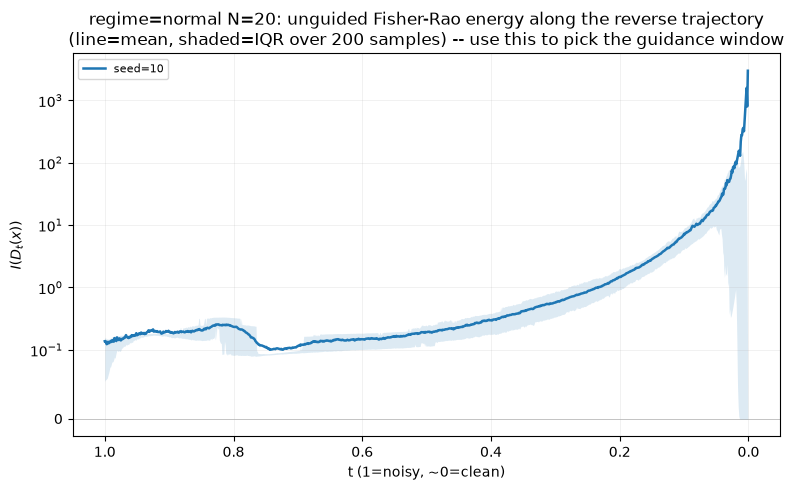

In [7]:
DIAG_SEEDS = config.get("diag_seeds", [config["seed"]])

def unguided_energy_trajectory(seed):
    torch.manual_seed(seed)
    z = torch.randn(config["n_samples"], d, device=device)
    base_step_fn = make_base_step_fn()
    energy_fn = make_knn_energy_fn()
    t_vals, I_mean, I_lo, I_hi = [], [], [], []
    with torch.no_grad():
        for step_idx in range(1, n_steps + 1):
            z_next = base_step_fn(z, step_idx)   # sets t_vec_holder["t"] for this step
            I = energy_fn(y_fn(z)).cpu().numpy()
            t_vals.append(t_vec_holder["t"][0].item())
            I_mean.append(I.mean())
            I_lo.append(np.percentile(I, 25))
            I_hi.append(np.percentile(I, 75))
            z = z_next
    return {"seed": seed, "t": np.array(t_vals), "I_mean": np.array(I_mean),
            "I_lo": np.array(I_lo), "I_hi": np.array(I_hi)}

diag_trajs = [unguided_energy_trajectory(s) for s in DIAG_SEEDS]

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10.colors
for i, tr in enumerate(diag_trajs):
    c = colors[i % len(colors)]
    ax.plot(tr["t"], tr["I_mean"], lw=1.8, color=c, label=f"seed={tr['seed']}", zorder=2)
    ax.fill_between(tr["t"], tr["I_lo"], tr["I_hi"], color=c, alpha=0.15, lw=0, zorder=1)

all_mean = np.concatenate([tr["I_mean"] for tr in diag_trajs])
finite = all_mean[np.isfinite(all_mean) & (all_mean != 0)]
linthresh = max(np.abs(finite).min(), 1e-12) if finite.size else 1e-6
ax.set_yscale("symlog", linthresh=linthresh)
ax.axhline(0, color="k", lw=0.5, alpha=0.3, zorder=0)
ax.invert_xaxis()
ax.set_xlabel("t (1=noisy, ~0=clean)")
ax.set_ylabel(r"$I(D_t(x))$")
ax.grid(alpha=0.25, lw=0.5)
ax.set_title(f"regime={REGIME} N={N}: unguided Fisher-Rao energy along the reverse trajectory\n"
             f"(line=mean, shaded=IQR over {config['n_samples']} samples) -- use this to pick the guidance window")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/unguided_energy_vs_t.png", dpi=150)
plt.show()

## Diagnostic: raw guidance gradient scale vs `t` (before clipping)


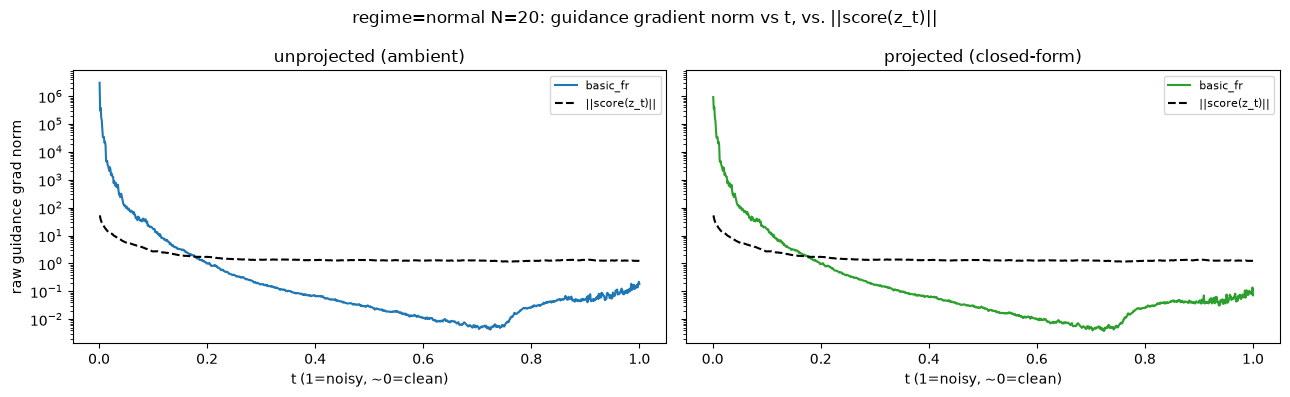

In [8]:
torch.manual_seed(config["seed"])
z = torch.randn(config["n_samples"], d, device=device)
base_step_fn = make_base_step_fn()
diag_energy_fns = {"basic_fr": make_knn_energy_fn()}
diag_projected_energy_fns = {"basic_fr": make_knn_projected_energy_fn()}

diag_rows = []
score_norm_rows = []
for step_idx in range(1, n_steps + 1):
    z_next = base_step_fn(z, step_idx)   # also sets t_vec_holder["t"] for this step
    t_val = t_vec_holder["t"][0].item()
    sigma2_val = sigma2(t_vec_holder["t"])[0].item()
    with torch.no_grad():
        score = -net(z, t_vec_holder["t"]) / sigma2(t_vec_holder["t"])[:, None].sqrt()
    score_norm_rows.append({"step_idx": step_idx, "t": t_val, "score_norm_mean": score.norm(dim=-1).mean().item()})
    for name, energy_fn in diag_energy_fns.items():
        grad, _, _ = driver.guidance_grad(y_fn, z, energy_fn, target_range=None)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": False,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    for name, energy_fn in diag_projected_energy_fns.items():
        grad, _, _ = driver.projected_guidance_grad(y_fn, z, energy_fn, JACOBIANS["projected"], target_range=None,
                                                      denoiser_jacobian_fn=denoiser_jacobian_fn)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": True,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    z = z_next

diag_df = pd.DataFrame(diag_rows)
score_norm_df = pd.DataFrame(score_norm_rows)

UNPROJ_COLORS = {"basic_fr": "tab:blue"}
PROJ_COLORS = {"basic_fr": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
for name, sub in diag_df[~diag_df["projected"]].groupby("method"):
    axes[0].plot(sub["t"], sub["grad_norm_mean"], label=name, color=UNPROJ_COLORS[name])
for name, sub in diag_df[diag_df["projected"]].groupby("method"):
    axes[1].plot(sub["t"], sub["grad_norm_mean"], label=name, color=PROJ_COLORS[name])

for ax, title in zip(axes, ["unprojected (ambient)", f"projected ({JACOBIAN_TYPE})"]):
    ax.plot(score_norm_df["t"], score_norm_df["score_norm_mean"], "--", color="black", label="||score(z_t)||")
    ax.set_xlabel("t (1=noisy, ~0=clean)"); ax.set_yscale("log"); ax.invert_xaxis()
    ax.set_title(title); ax.legend(fontsize=8)
axes[0].set_ylabel("raw guidance grad norm")
fig.suptitle(f"regime={REGIME} N={N}: guidance gradient norm vs t, vs. ||score(z_t)||")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/grad_norm_vs_t.png", dpi=120); plt.show()

## Metrics

- `mem_ratio`: fraction with `dist(nearest atom) / dist(2nd-nearest atom) < mem_ratio_threshold`.
- `fidelity_mse`: mean squared distance to the manifold, over non-memorized samples only (a
  memorized sample already sits near an atom, so including it would reward memorization).
  `NaN` if every sample is memorized.

In [9]:
u_scan = torch.linspace(-4.0, 4.0, 4000, device=device)
curve_scan = torch.stack([u_scan, 0.6 * torch.sin(2 * u_scan)], dim=-1)   # [S, 2]

def dist_to_manifold(X):
    return torch.cdist(X, curve_scan).min(dim=1).values

def is_memorized(X, atoms, thresh):
    d2 = torch.cdist(X, atoms)
    top2 = torch.topk(d2, 2, largest=False, dim=1).values   # [B, 2], ascending
    ratio = top2[:, 0] / top2[:, 1].clamp(min=1e-8)
    return ratio.lt(thresh)

def evaluate(X):
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    unmem = ~mem
    fidelity = dist_to_manifold(X[unmem]).pow(2).mean().item() if unmem.any() else float("nan")
    return {
        "mem_ratio": mem.float().mean().item(),
        "fidelity_mse": fidelity,
    }

In [10]:
def run_condition(guidance_fn, eta, progress_lo, progress_hi):
    torch.manual_seed(config["seed"])
    z_init = torch.randn(config["n_samples"], d, device=device)
    if guidance_fn is None:
        x = z_init
        base_step_fn = make_base_step_fn()
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                x = base_step_fn(x, step_idx)
        return x.detach()
    z_final, _ = driver.guided_reverse_loop(
        z_init, n_steps, make_base_step_fn(), guidance_fn,
        progress_lo=progress_lo, progress_hi=progress_hi, ell=config["ell"], trust_region=eta)
    return z_final.detach()

X_unguided = run_condition(None, 0.0, 0.0, 1.0)
baseline = {"method": "unguided", "jacobian": "unprojected", "window": "n/a", "eta": 0.0,
            **evaluate(X_unguided)}
print(baseline)

{'method': 'unguided', 'jacobian': 'unprojected', 'window': 'n/a', 'eta': 0.0, 'mem_ratio': 0.3400000035762787, 'fidelity_mse': 0.0007231510826386511}


## Full sweep: method x jacobian x window x lambda

In [11]:
rows = [baseline]
samples_cache = {("unguided", "unprojected", "n/a", 0.0): X_unguided}

for method in ENERGY_FACTORIES:
    for jacobian_name, jacobian_fn in JACOBIANS.items():
        for window_name, (progress_lo, progress_hi) in windows.items():
            guidance_fn = make_guidance_fn(method, jacobian_name)
            for eta in config["etas"]:
                X = run_condition(guidance_fn, eta, progress_lo, progress_hi)
                row = {"method": method, "jacobian": jacobian_name, "window": window_name,
                       "eta": eta, **evaluate(X)}
                rows.append(row)
                samples_cache[(method, jacobian_name, window_name, eta)] = X

df = pd.DataFrame(rows)
print(f"{len(df)} configs run.")
df.to_csv(f"{OUT_DIR}/fr_sweep_results.csv", index=False)
df.sort_values(["method", "jacobian", "window", "eta"])

3 configs run.


,method,jacobian,window,eta,mem_ratio,fidelity_mse
2,basic_fr,projected,normal,0.75,0.00,0.001065
1,basic_fr,unprojected,normal,0.75,0.00,0.013414
0,unguided,unprojected,n/a,0.00,0.34,0.000723


## Combined error and ranking

`fidelity_mse` and `mem_ratio` live on different scales, so normalize each by the unguided
baseline and add: `combined_error = fidelity_mse/baseline_fidelity + mem_ratio/baseline_mem`.
2.0 = no change from unguided; lower is better on both.

In [12]:
df["fidelity_rel"] = df["fidelity_mse"] / baseline["fidelity_mse"]
df["mem_rel"] = df["mem_ratio"] / baseline["mem_ratio"]
df["combined_error"] = df["fidelity_rel"]* 0.01 + df["mem_rel"] 
df.to_csv(f"{OUT_DIR}/fr_sweep_results.csv", index=False)

guided = df[df["method"] != "unguided"]

print(f"regime={REGIME} N={N}  baseline combined_error = {2.0:.3f} (fidelity_rel=1.0 + mem_rel=1.0)\n")
print("Top 15 configs by combined_error (lower is better):")
top = guided.sort_values("combined_error").head(15)
pd.set_option("display.width", 200)
print(top[["method", "jacobian", "window", "eta", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

regime=normal N=20  baseline combined_error = 2.000 (fidelity_rel=1.0 + mem_rel=1.0)

Top 15 configs by combined_error (lower is better):
  method    jacobian window  eta  mem_ratio  fidelity_mse  combined_error
basic_fr   projected normal 0.75        0.0      0.001065        0.014721
basic_fr unprojected normal 0.75        0.0      0.013414        0.185500


In [13]:
print("Best achievable combined_error per (method, jacobian) i.e. best case over all windows:\n")
best_per_method = guided.loc[guided.groupby(["method", "jacobian"])["combined_error"].idxmin()]
best_per_method = best_per_method.sort_values("combined_error")
print(best_per_method[["method", "jacobian", "window", "eta", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

print("\nMedian combined_error per (method, jacobian), across all swept windows"
      " -- how forgiving the method is to hyperparameter choice, not just its best case:\n")
robustness = guided.groupby(["method", "jacobian"])["combined_error"].median().sort_values()
print(robustness.to_string())

Best achievable combined_error per (method, jacobian) i.e. best case over all windows:

  method    jacobian window  eta  mem_ratio  fidelity_mse  combined_error
basic_fr   projected normal 0.75        0.0      0.001065        0.014721
basic_fr unprojected normal 0.75        0.0      0.013414        0.185500

Median combined_error per (method, jacobian), across all swept windows -- how forgiving the method is to hyperparameter choice, not just its best case:

method    jacobian   
basic_fr  projected      0.014721
          unprojected    0.185500


## Which methods stay close to the manifold *and* improve memorization

In [14]:
FIDELITY_MAX = baseline["fidelity_mse"]  * 1000000
MEM_MAX = baseline["mem_ratio"] 

qualifying = guided[(guided["fidelity_mse"] < FIDELITY_MAX) & (guided["mem_ratio"] < MEM_MAX)].sort_values("combined_error")
print(f"{len(qualifying)}/{len(guided)} configs satisfy fidelity_mse < {FIDELITY_MAX} and mem_ratio < {MEM_MAX}\n")

print("By method/jacobian, how many configs qualify (robustness of the win, not just best case):")
print(qualifying.groupby(["method", "jacobian"]).size().sort_values(ascending=False).to_string())

print("\nTop 10 qualifying configs:")
print(qualifying.head(10)[["method", "jacobian", "window", "eta", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

2/2 configs satisfy fidelity_mse < 723.1510826386511 and mem_ratio < 0.3400000035762787

By method/jacobian, how many configs qualify (robustness of the win, not just best case):
method    jacobian   
basic_fr  projected      1
          unprojected    1

Top 10 qualifying configs:
  method    jacobian window  eta  mem_ratio  fidelity_mse  combined_error
basic_fr   projected normal 0.75        0.0      0.001065        0.014721
basic_fr unprojected normal 0.75        0.0      0.013414        0.185500


## Scatter view: unguided vs the two best qualifying configs

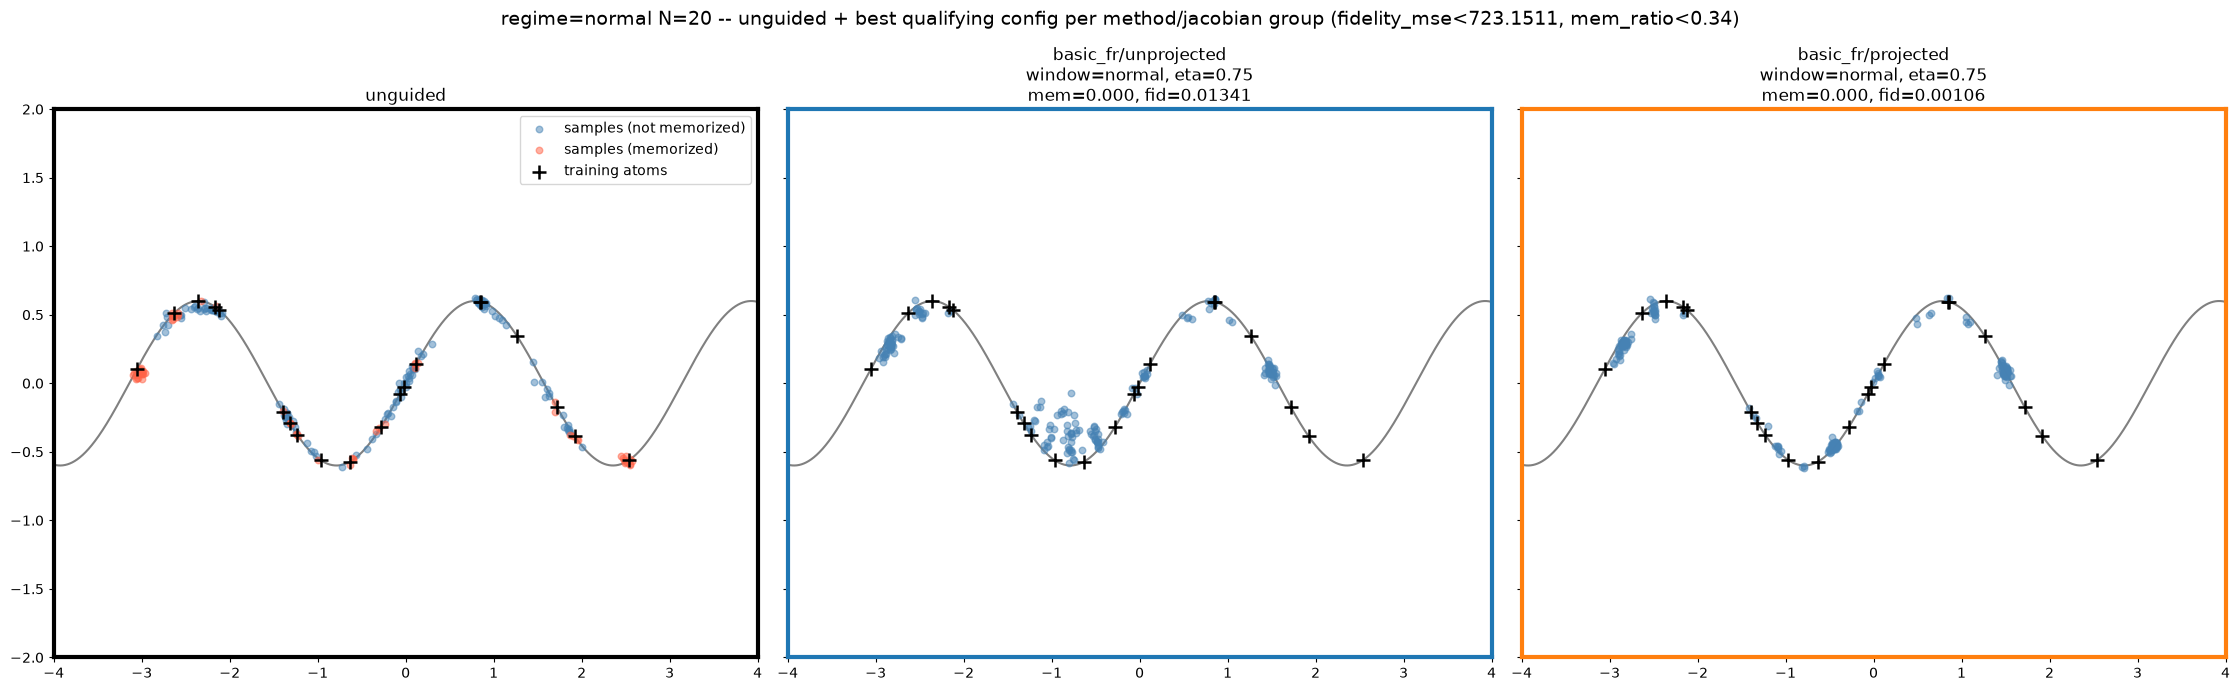

In [15]:
top2 = qualifying.head(2)   # kept for later cells
GROUPS = [(m, j) for m in ENERGY_FACTORIES for j in JACOBIANS]
_group_palette = plt.cm.tab10.colors
GROUP_COLORS = {g: _group_palette[i % len(_group_palette)] for i, g in enumerate(GROUPS)}

best_per_group = {}
for method, jacobian in GROUPS:
    sub = qualifying[(qualifying.method == method) & (qualifying.jacobian == jacobian)]
    if len(sub):
        best_per_group[(method, jacobian)] = sub.sort_values("combined_error").iloc[0]
missing = [g for g in GROUPS if g not in best_per_group]
if missing:
    print(f"no qualifying config for: {missing}")

picks = [("unguided", "unprojected", "n/a", 0.0)] + [
    (row["method"], row["jacobian"], row["window"], row["eta"])
    for row in best_per_group.values()
]

N_COLS = 3
n_rows = (len(picks) + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(7.5 * N_COLS, 7 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()
for ax, key in zip(axes, picks):
    X = samples_cache[key]
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="gray", lw=1.5, zorder=0)
    ax.scatter(X[~mem, 0].cpu(), X[~mem, 1].cpu(), s=22, color="steelblue", alpha=0.5,
               label="samples (not memorized)", zorder=1)
    ax.scatter(X[mem, 0].cpu(), X[mem, 1].cpu(), s=22, color="tomato", alpha=0.5,
               label="samples (memorized)", zorder=2)
    ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=110, color="black",
               marker="+", linewidths=1.8, label="training atoms", zorder=5)
    method, jacobian, window, eta = key
    if method == "unguided":
        title = "unguided"
        spine_color = "black"
    else:
        row = qualifying[(qualifying.method == method) & (qualifying.jacobian == jacobian) &
                          (qualifying.window == window) & (qualifying.eta == eta)].iloc[0]
        title = (f"{method}/{jacobian}\nwindow={window}, eta={eta:g}" +
                 f"\nmem={row.mem_ratio:.3f}, fid={row.fidelity_mse:.5f}")
        spine_color = GROUP_COLORS[(method, jacobian)]
    for spine in ax.spines.values():
        spine.set_edgecolor(spine_color); spine.set_linewidth(3)
    ax.set_title(title, fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(-2, 2)
for ax in axes[len(picks):]:
    ax.axis("off")
axes[0].legend(fontsize=10)
plt.suptitle(f"regime={REGIME} N={N} -- unguided + best qualifying config per method/jacobian group "
             f"(fidelity_mse<{np.round(FIDELITY_MAX, 4)}, mem_ratio<{np.round(MEM_MAX, 3)})", fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fr_comparison.png", dpi=120); plt.show()